In [24]:
import pandas as pd
import numpy as np

In [5]:
cal_data=pd.read_csv("/Users/varadkulkarni/AI-Practice Projects/product-forcasting/m5-forecasting-accuracy/calendar.csv")
sales_train_eval=pd.read_csv("/Users/varadkulkarni/AI-Practice Projects/product-forcasting/m5-forecasting-accuracy/sales_train_evaluation.csv")
sales_train_val=pd.read_csv("/Users/varadkulkarni/AI-Practice Projects/product-forcasting/m5-forecasting-accuracy/sales_train_validation.csv")
sell_prices=pd.read_csv("/Users/varadkulkarni/AI-Practice Projects/product-forcasting/m5-forecasting-accuracy/sell_prices.csv")

In [6]:
cal_data.head()

,date,wm_yr_wk,weekday,wday,month,year,d,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI
0,2011-01-29,11101,Saturday,1,1,2011,d_1,NaN,NaN,NaN,NaN,0,0,0
1,2011-01-30,11101,Sunday,2,1,2011,d_2,NaN,NaN,NaN,NaN,0,0,0
2,2011-01-31,11101,Monday,3,1,2011,d_3,NaN,NaN,NaN,NaN,0,0,0
3,2011-02-01,11101,Tuesday,4,2,2011,d_4,NaN,NaN,NaN,NaN,1,1,0
4,2011-02-02,11101,Wednesday,5,2,2011,d_5,NaN,NaN,NaN,NaN,1,0,1


In [8]:
sales_train_eval.head()

,id,item_id,dept_id,cat_id,store_id,state_id,d_1,d_2,d_3,d_4,...,d_1932,d_1933,d_1934,d_1935,d_1936,d_1937,d_1938,d_1939,d_1940,d_1941
0,HOBBIES_1_001_CA_1_evaluation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,2,4,0,0,0,0,3,3,0,1
1,HOBBIES_1_002_CA_1_evaluation,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,0,1,2,1,1,0,0,0,0,0
2,HOBBIES_1_003_CA_1_evaluation,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,1,0,2,0,0,0,2,3,0,1
3,HOBBIES_1_004_CA_1_evaluation,HOBBIES_1_004,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,1,1,0,4,0,1,3,0,2,6
4,HOBBIES_1_005_CA_1_evaluation,HOBBIES_1_005,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,0,0,0,2,1,0,0,2,1,0


In [9]:
sales_train_val.head()

,id,item_id,dept_id,cat_id,store_id,state_id,d_1,d_2,d_3,d_4,...,d_1904,d_1905,d_1906,d_1907,d_1908,d_1909,d_1910,d_1911,d_1912,d_1913
0,HOBBIES_1_001_CA_1_validation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,1,3,0,1,1,1,3,0,1,1
1,HOBBIES_1_002_CA_1_validation,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
2,HOBBIES_1_003_CA_1_validation,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,2,1,2,1,1,1,0,1,1,1
3,HOBBIES_1_004_CA_1_validation,HOBBIES_1_004,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,1,0,5,4,1,0,1,3,7,2
4,HOBBIES_1_005_CA_1_validation,HOBBIES_1_005,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,2,1,1,0,1,1,2,2,2,4


In [13]:
sell_prices.head()

,store_id,item_id,wm_yr_wk,sell_price
0,CA_1,HOBBIES_1_001,11325,9.58
1,CA_1,HOBBIES_1_001,11326,9.58
2,CA_1,HOBBIES_1_001,11327,8.26
3,CA_1,HOBBIES_1_001,11328,8.26
4,CA_1,HOBBIES_1_001,11329,8.26


In [14]:
# Filter to FOODS category and CA_1 store
foods_ca1 = sales_train_eval[
    (sales_train_eval['cat_id'] == 'FOODS') & 
    (sales_train_eval['store_id'] == 'CA_1')
].copy()
 
print(f"Original products: {len(sales_train_eval)}")
print(f"FOODS + CA_1 products: {len(foods_ca1)}")
print(f"Reduction: {len(foods_ca1)/len(sales_train_eval):.1%}")

Original products: 30490
FOODS + CA_1 products: 1437
Reduction: 4.7%


In [ ]:
# Check departments within FOODS
print("Departments in FOODS category:")
print(foods_ca1['dept_id'].value_counts())

# Let's look at the top departments
top_depts = foods_ca1['dept_id'].value_counts().head(5).index.tolist()
print(f"\nTop 5 departments: {top_depts}")





Departments in FOODS category:
dept_id
FOODS_3    823
FOODS_2    398
FOODS_1    216
Name: count, dtype: int64

Top 5 departments: ['FOODS_3', 'FOODS_2', 'FOODS_1']


In [21]:
# Get actual dates from calendar data
start_date = cal_data[cal_data['d'] == 'd_1']['date'].values[0]
end_date = cal_data[cal_data['d'] == 'd_1941']['date'].values[0]
train_end_date = cal_data[cal_data['d'] == 'd_1913']['date'].values[0]
test_start_date = cal_data[cal_data['d'] == 'd_1914']['date'].values[0]

print(f"Date range: {start_date} to {end_date}")
print(f"Training period: {start_date} to {train_end_date}")
print(f"Test period: {test_start_date} to {end_date}")
print(f"\nTraining days: d_1 to d_1913 (1913 days)")
print(f"Test days: d_1914 to d_1941 (28 days)")

Date range: 2011-01-29 to 2016-05-22
Training period: 2011-01-29 to 2016-04-24
Test period: 2016-04-25 to 2016-05-22

Training days: d_1 to d_1913 (1913 days)
Test days: d_1914 to d_1941 (28 days)


Sample product IDs:
['FOODS_1_001_CA_1_evaluation', 'FOODS_1_002_CA_1_evaluation', 'FOODS_1_003_CA_1_evaluation']


Matplotlib is building the font cache; this may take a moment.


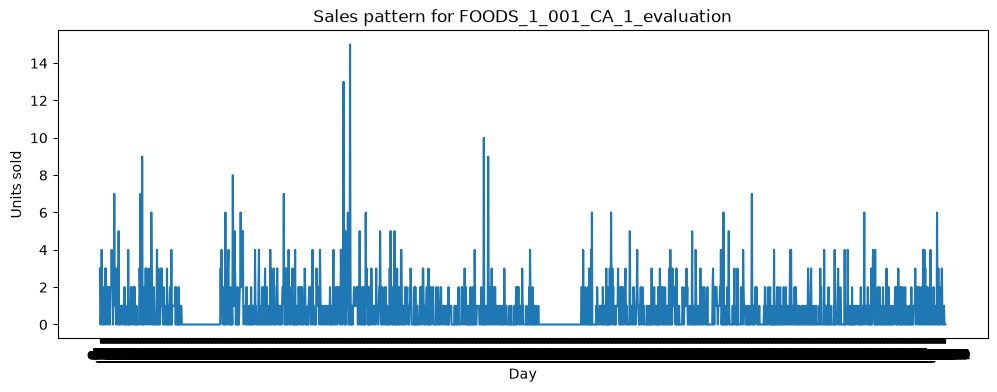

In [22]:
# Sample a few products to see sales patterns
sample_products = foods_ca1.head(3)
print("Sample product IDs:")
print(sample_products['id'].tolist())

# Check for zeros (intermittent demand)
day_columns = [col for col in foods_ca1.columns if col.startswith('d_')]
sample_sales = sample_products[day_columns].T
sample_sales.columns = sample_products['id'].tolist()

# Plot first sample product
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 4))
plt.plot(sample_sales.iloc[:, 0])
plt.title(f"Sales pattern for {sample_sales.columns[0]}")
plt.xlabel("Day")
plt.ylabel("Units sold")
plt.show()

In [25]:
# Calculate numerical statistics for sales distribution
day_columns = [col for col in foods_ca1.columns if col.startswith('d_')]

# Overall statistics
all_sales = foods_ca1[day_columns].values.flatten()
print("Overall Sales Statistics:")
print(f"Mean: {all_sales.mean():.2f}")
print(f"Median: {np.median(all_sales):.2f}")
print(f"Std: {all_sales.std():.2f}")
print(f"Min: {all_sales.min()}")
print(f"Max: {all_sales.max()}")
print(f"Zero percentage: {(all_sales == 0).mean():.1%}")

# Per-product statistics
product_means = foods_ca1[day_columns].mean(axis=1)
print(f"\nPer-Product Statistics:")
print(f"Average daily sales per product: {product_means.mean():.2f}")
print(f"Product with highest avg sales: {product_means.max():.2f}")
print(f"Product with lowest avg sales: {product_means.min():.2f}")

# Sales distribution by department
for dept in foods_ca1['dept_id'].unique():
    dept_data = foods_ca1[foods_ca1['dept_id'] == dept]
    dept_sales = dept_data[day_columns].values.flatten()
    print(f"\n{dept} Department:")
    print(f"  Mean daily sales: {dept_sales.mean():.2f}")
    print(f"  Zero percentage: {(dept_sales == 0).mean():.1%}")

Overall Sales Statistics:
Mean: 1.96
Median: 0.00
Std: 5.38
Min: 0
Max: 648
Zero percentage: 56.9%

Per-Product Statistics:
Average daily sales per product: 1.96
Product with highest avg sales: 66.39
Product with lowest avg sales: 0.04

FOODS_1 Department:
  Mean daily sales: 1.38
  Zero percentage: 59.1%

FOODS_2 Department:
  Mean daily sales: 1.17
  Zero percentage: 63.8%

FOODS_3 Department:
  Mean daily sales: 2.50
  Zero percentage: 53.0%


In [26]:
# Define train and test day columns
train_days = [f'd_{i}' for i in range(1, 1914)]  # d_1 to d_1913
test_days = [f'd_{i}' for i in range(1914, 1942)]  # d_1914 to d_1941

print(f"Training days: {len(train_days)}")
print(f"Test days: {len(test_days)}")

# Split the data
train_data = foods_ca1[['id', 'dept_id'] + train_days].copy()
test_data = foods_ca1[['id', 'dept_id'] + test_days].copy()

print(f"Training data shape: {train_data.shape}")
print(f"Test data shape: {test_data.shape}")

Training days: 1913
Test days: 28
Training data shape: (1437, 1915)
Test data shape: (1437, 30)


In [28]:
train_data.to_csv("train_data.csv", index=False)
test_data.to_csv("test_data.csv", index=False)